# 04 — Meta-analysis: the Chahine rule across the corpus

The question HyCAN-DB exists to answer (manual §1.3): once the whole literature is pooled with explicit quality weighting, does H₂ uptake on carbons scale with BET area as the Chahine rule claims — **1 wt% per 500 m²/g at 77 K**? All estimates come from `hycan.meta`, which is unit-tested in `tests/test_meta.py`.

In [1]:
# Setup: find the repo root so this notebook runs from anywhere, then import.
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
_d = Path.cwd()
while _d != _d.parent and not (_d / 'pyproject.toml').exists():
    _d = _d.parent
os.chdir(_d); sys.path.insert(0, str(_d / 'src'))
import pandas as pd
import matplotlib.pyplot as plt
from hycan.load import load_dataset, analysis_subset
from hycan import meta
from hycan.plotting import set_house_style
set_house_style()
df = load_dataset()
print('dataset:', df.shape[0], 'rows,', df['paper_id'].nunique(), 'papers')

dataset: 521 rows, 51 papers


## The analysis subset for this question
77 K, §12.3-filtered, wt% present, a **method-confirmed** BET area (§10.3 — an area is used only where `surface_area_method == BET`), and `total`-uptake rows excluded (the rule bounds *adsorbed* uptake). This is exactly the set `figures/fig3_chahine` plots.

In [2]:
ch = meta.chahine_subset(df)
print('Chahine subset:', len(ch), 'rows,', ch['paper_id'].nunique(), 'papers')
print('uptake_type:', ch['uptake_type'].value_counts().to_dict())

Chahine subset: 205 rows, 30 papers
uptake_type: {'unspecified': 121, 'excess': 84}


## Hierarchical fit — the rule test
The rule is *proportional* (no intercept), so the test is a through-origin fit of uptake on BET with a **random intercept per paper**. The random effect matters: measurements from one paper are correlated, and ignoring that both inflates confidence and lets a few large-area papers dominate (manual §14.2, §E).

In [3]:
res = meta.chahine_mixedlm(df, through_origin=True)
lo, hi = res['wt_pct_per_500_m2_ci95']
print(f"slope          : {res['slope_wt_pct_per_m2']:.5f} wt%/(m2/g)")
print(f"per 500 m2/g   : {res['wt_pct_per_500_m2']:.3f}  (Chahine rule = 1.0)")
print(f"95% CI         : ({lo:.3f}, {hi:.3f})  per 500 m2/g")
print(f"equivalently   : 1 wt% per {res['m2_per_g_per_wt_pct']:.0f} m2/g")
print(f"CI covers 1.0? : {res['meets_rule']}")

slope          : 0.00143 wt%/(m2/g)
per 500 m2/g   : 0.716  (Chahine rule = 1.0)
95% CI         : (0.622, 0.809)  per 500 m2/g
equivalently   : 1 wt% per 699 m2/g
CI covers 1.0? : False


**Finding.** The corpus reaches **≈0.72 wt% per 500 m²/g (95% CI ≈ 0.62–0.81)** — about **1 wt% per ~700 m²/g**, roughly **30% below** the canonical rule, and the confidence interval excludes 1.0. Pooled across the literature with paper-level weighting, the Chahine rule systematically *overstates* the H₂ uptake carbons actually achieve at 77 K.

### Why the hierarchical estimate, not a naive fit
A plain through-origin OLS gives a steeper slope, because papers with many high-area points pull it up. The gap between the two is the hazard the random-effects model removes.

In [4]:
ts = meta.tier_sensitivity(df)
print(f"naive OLS (all tiers)   : {ts['all_tiers']['ols_origin_wt_pct_per_500_m2']:.3f} per 500 m2/g")
print(f"hierarchical (all tiers): {ts['all_tiers']['mixedlm_wt_pct_per_500_m2']:.3f} per 500 m2/g")

naive OLS (all tiers)   : 0.863 per 500 m2/g
hierarchical (all tiers): 0.716 per 500 m2/g


### Is the relationship even proportional?
Refitting with a free intercept asks whether uptake really passes through the origin.

In [5]:
fi = meta.chahine_mixedlm(df, through_origin=False)
print(f"intercept      : {fi['intercept_wt_pct']:.2f} wt%")
print(f"marginal slope : {fi['wt_pct_per_500_m2']:.3f} per 500 m2/g")

intercept      : 1.11 wt%
marginal slope : 0.644 per 500 m2/g


The intercept is **positive (~1.1 wt%)**: low-area carbons still adsorb a baseline amount, and the marginal gain per unit area is shallower still. The rule's strict proportionality is an approximation — there is an offset the single-constant rule cannot express.

## Sensitivity to reproducibility tier
If the shortfall were an artifact of low-quality data, restricting to the best tiers would push the slope toward 1.0. It does not.

In [6]:
import pandas as pd
rows = []
for lab, e in ts.items():
    ci = e.get('mixedlm_ci95')
    rows.append({'subset': lab, 'n_rows': e['n_obs'], 'n_papers': e['n_papers'],
                 'hier_per_500': round(e['mixedlm_wt_pct_per_500_m2'], 3),
                 'CI_low': round(ci[0],3) if ci else None,
                 'CI_high': round(ci[1],3) if ci else None})
print(pd.DataFrame(rows).to_string(index=False))

   subset  n_rows  n_papers  hier_per_500  CI_low  CI_high
all_tiers     205        30         0.716   0.622    0.809
  tier_AB     191        28         0.695   0.606    0.783
   tier_A      53         9         0.640   0.520    0.759


Across All / Tier A–B / Tier A the estimate stays near **0.64–0.72 per 500 m²/g** and never approaches 1.0 — if anything the highest-quality subset is slightly *lower*. The shortfall is a property of the field, not of the inclusion threshold.

## Publication-bias check
A paper-level funnel: each paper's mean deviation from the Chahine prediction against its precision (1/SE of that mean). An Egger-style intercept test flags funnel asymmetry — the small-study signature of publication bias. **Caveat:** the papers report no per-value uncertainty, so precision here is a within-paper dispersion proxy; read this as suggestive, not a formal small-study test.

n_papers_in_test      : 23
mean_effect_wt_pct    : -0.14981358263454675
egger_intercept       : -6.810120739460009
egger_intercept_p     : 0.005641613779358066
egger_slope           : 1.6399783491948159
asymmetry_detected    : True


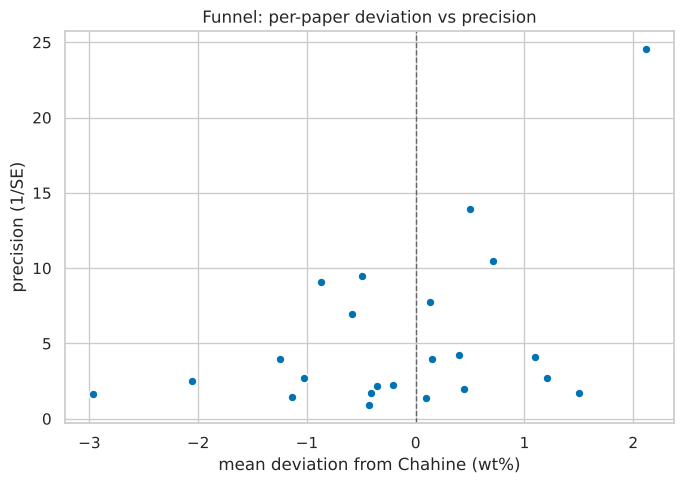

In [7]:
pb, funnel = meta.publication_bias(df)
for k, v in pb.items():
    print(f'{k:22s}: {v}')
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(funnel['effect'], funnel['precision'], s=40, edgecolor='white')
ax.axvline(0, color='0.4', ls='--', lw=1)
ax.set_xlabel('mean deviation from Chahine (wt%)'); ax.set_ylabel('precision (1/SE)')
ax.set_title('Funnel: per-paper deviation vs precision'); plt.tight_layout(); plt.show()

The mean per-paper deviation is slightly **negative** (papers sit below the rule on average), consistent with the hierarchical result, and the Egger intercept is nonzero at p≈0.006 — suggestive funnel asymmetry. With the proxy-SE caveat above, treat this as corroborating the shortfall and the §7.4 search bias toward the controversy literature, not as a definitive small-study test.

## Conclusions
1. **The Chahine rule overstates pooled carbon H₂ uptake by ~30%** at 77 K: ≈0.72 wt% per 500 m²/g (95% CI 0.62–0.81), i.e. 1 wt% per ~700 m²/g.
2. The result is **robust to reproducibility tier** and to the hierarchical-vs-naive modelling choice (naive OLS overstates it).
3. The uptake–area relationship carries a **positive baseline offset**, so strict proportionality is an approximation.
4. A funnel/Egger check is **consistent with** a mild downward, controversy-weighted skew, with the stated proxy-SE limitation.

These are corpus-level statements no single paper can make, which is the point of the database.